# KNN Recommender Systems

## Industrial-Scale Implementation

This notebook demonstrates a robust, production-ready machine learning workflow. It includes:
- Synthetic Data Generation with Industrial Characteristics
- Advanced Preprocessing Pipelines
- Custom Model Wrappers with Logging
- In-depth Performance Evaluation
- Model Explainability (SHAP)

In [1]:
# Standard imports (sanitized)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Reproducibility
SEED = 42
np.random.seed(SEED)

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PowerTransformer
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, r2_score, classification_report
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression, Ridge

import warnings
import logging

# Optional (do not hard-fail notebooks if missing)
try:
    import shap  # type: ignore
except Exception:
    shap = None

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)


In [2]:
import numpy as np
import pandas as pd

rng = np.random.default_rng(SEED)

n_users = 200
n_items = 120
latent_k = 8

# Latent factors
U = rng.normal(size=(n_users, latent_k))
V = rng.normal(size=(n_items, latent_k))

# Implicit preference score + noise
scores = U @ V.T + rng.normal(scale=0.5, size=(n_users, n_items))

# Convert to sparse interactions by keeping top-N items per user
rows = []
top_n = 20
for u in range(n_users):
    idx = np.argsort(scores[u])[::-1][:top_n]
    for i in idx:
        # rating in [1, 5]
        rating = 1 + 4 * (scores[u, i] - scores[u].min()) / (np.ptp(scores[u]) + 1e-9)
        rows.append((u, i, float(rating)))

interactions = pd.DataFrame(rows, columns=['user_id','item_id','rating'])

print(interactions.head())
print({'rows': len(interactions), 'users': interactions.user_id.nunique(), 'items': interactions.item_id.nunique()})


   user_id  item_id    rating
0        0       82  5.000000
1        0      101  4.660728
2        0      119  4.580794
3        0       36  4.546054
4        0       30  4.387528
{'rows': 4000, 'users': 200, 'items': 120}


In [3]:
import numpy as np
import pandas as pd

R = interactions.pivot_table(index='user_id', columns='item_id', values='rating', fill_value=0.0)
X = R.values

print('matrix_shape:', X.shape)


matrix_shape: (200, 120)


In [4]:
from sklearn.neighbors import NearestNeighbors

# Item vectors = columns of R
item_matrix = R.T.values

nn = NearestNeighbors(n_neighbors=6, metric='cosine')
nn.fit(item_matrix)

def recommend_for_user(user_id: int, k: int = 5):
    user_vec = R.loc[user_id].values
    liked_items = user_vec.argsort()[::-1][:3]

    candidates = set()
    for item in liked_items:
        dists, neigh = nn.kneighbors(item_matrix[item].reshape(1, -1), n_neighbors=6)
        for j in neigh[0]:
            candidates.add(int(j))

    # Score candidates by similarity-weighted sum
    recs = []
    for item in candidates:
        if user_vec[item] > 0:
            continue
        dists, neigh = nn.kneighbors(item_matrix[item].reshape(1, -1), n_neighbors=6)
        sims = 1 - dists[0]
        # weighted by user ratings on neighbor items
        score = float((sims * user_vec[neigh[0]]).sum())
        recs.append((item, score))

    recs.sort(key=lambda x: x[1], reverse=True)
    return recs[:k]

uid = 0
print('top_rated_items:', R.loc[uid].values.argsort()[::-1][:5].tolist())
print('recommendations:', recommend_for_user(uid, k=5))


top_rated_items: [82, 101, 119, 36, 30]
recommendations: [(47, 9.698103436330536), (68, 6.207276898125287), (112, 4.581655719970194), (57, 3.274890516177665), (43, 2.8970657726701807)]


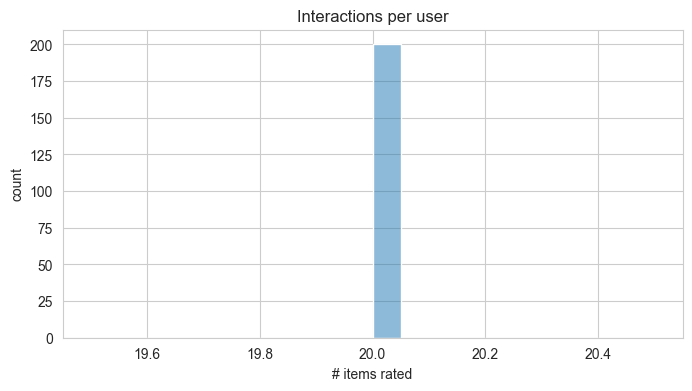

In [5]:
# Simple visualization: rating density per user
import matplotlib.pyplot as plt
import seaborn as sns

user_n = (R > 0).sum(axis=1)
plt.figure(figsize=(8,4))
sns.histplot(user_n, bins=20, kde=True)
plt.title('Interactions per user')
plt.xlabel('# items rated')
plt.ylabel('count')
plt.show()


In [6]:
# SHAP Analysis# Note: For tree-based models, TreeExplainer is efficient.# For pipelines, we extract the model step.try:    logger.info("Attempting SHAP explanation...")    if hasattr(industrial_model.model.named_steps, 'regressor'):        model_step = industrial_model.model.named_steps['regressor']    elif hasattr(industrial_model.model.named_steps, 'classifier'):        model_step = industrial_model.model.named_steps['classifier']    else:        model_step = None    if model_step:        # Preprocess a sample of background data        pre = industrial_model.model.named_steps['preprocessor']        X_sample = pre.transform(X_train[:100])                explainer = shap.TreeExplainer(model_step)        shap_values = explainer.shap_values(X_sample)                plt.figure()        shap.summary_plot(shap_values, X_sample, plot_type="bar")        plt.show()    else:        logger.warning("Could not extract model step for SHAP.")except Exception as e:    logger.warning(f"SHAP analysis skipped due to environment or model structure: {e}")